In [2]:
#What is CCA??
# Complete CAse Analysis
# in this we will discard those rows that are having NULL values in any of the columns


# Assumptions for CCA:
# 1. Data is Missing Completely at Random (MCAR): The missing data is independent of both observed and unobserved data. In other words, the likelihood of a data point being missing is not related to any other variable in the dataset.

# Advantages - 
# 1. Simplicity: CCA is straightforward to implement and understand, making it a popular choice for handling missing data.
#3 . Preserves variable distribution(if data is MCAR)

# Disadvantages - 
# 1. Loss of Data: CCA can lead to a significant reduction in the sample size, especially if there are many variables with missing values. This can result in a loss of statistical power and may bias the results if the missing data is not MCAR.
# 2. Bias: If the data is not MCAR, CCA can introduce bias into the analysis, as the remaining complete cases may not be representative of the entire dataset.
#3. When using our model in production, we may encounter missing values in the input data, which can lead to errors or inaccurate predictions if not handled properly.



# When to use CCA:
#1. MCAR
#2. When the proportion of missing data is small (e.g., less than 5-10%), as the loss of data may not significantly impact the analysis.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
df = pd.read_csv('data_science_job.csv')
df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [ ]:
df.isnull().mean() *100
# cca will be applied to the columns having less than 5% missing values 

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [9]:
df.shape

(19158, 13)

In [12]:
cols = [var for var in df.columns if df[var].isnull().mean()*100 <5 and df[var].isnull().mean()*100 >0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [13]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
5515,0.624,no_enrollment,Graduate,11.0,106.0
6189,0.878,Part time course,Masters,20.0,NaN
8385,0.887,no_enrollment,Graduate,20.0,96.0
8250,0.836,no_enrollment,Graduate,20.0,180.0
5441,0.920,Full time course,Graduate,7.0,70.0


In [14]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [16]:
new_df = df[cols].dropna()
new_df.shape

(17182, 5)

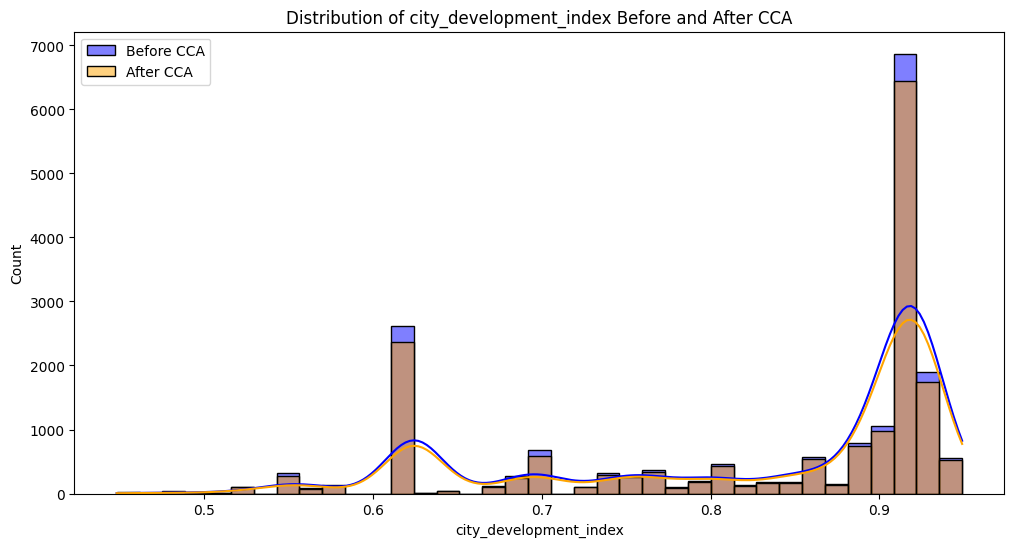

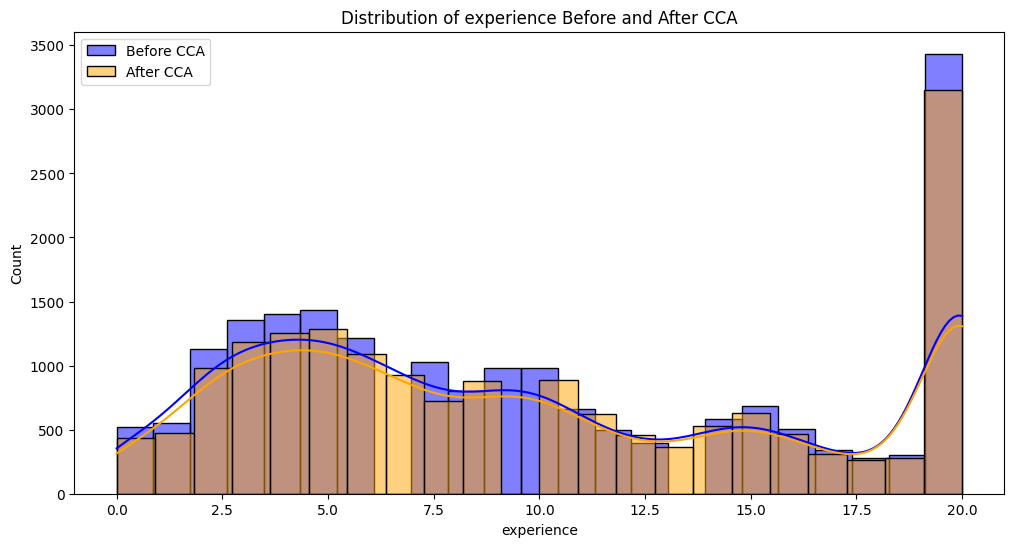

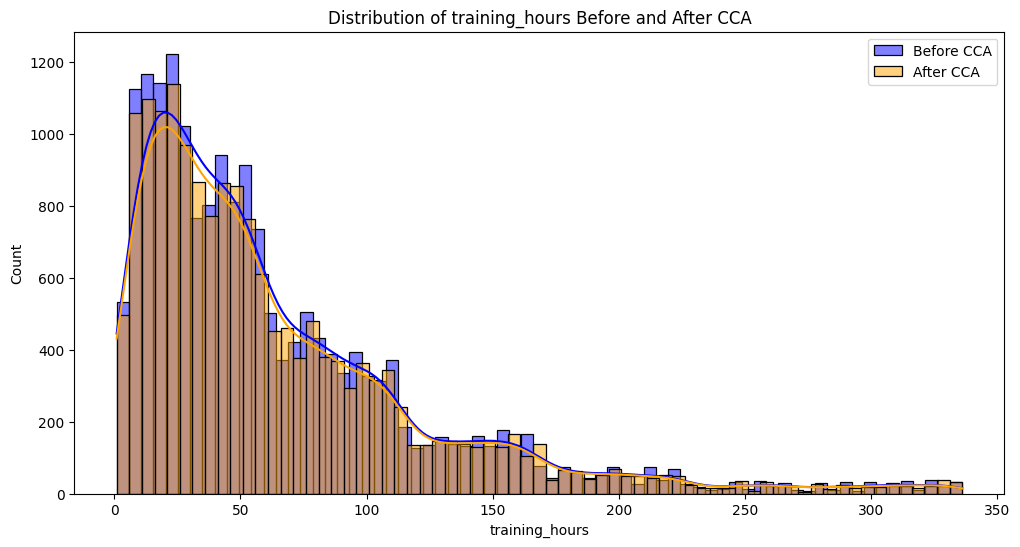

In [24]:
# after applying cca to check draw histogram on the columns you applied cca before and after applying it to check the distribution of the data is preserved or not but only on numerical columns
numerical_cols = [var for var in cols if df[var].dtype in ['int64', 'float64']]
for var in numerical_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[var], kde=True, color='blue', label='Before CCA')
    sns.histplot(new_df[var], kde=True, color='orange', label='After CCA')
    plt.title(f'Distribution of {var} Before and After CCA')
    plt.legend()
    plt.show()

In [ ]:
# the curves are almost overlapping which means the distribution of the data is preserved after applying cca
#so data in  numerical_cols was mcar

In [28]:
# for categorical columns u need to check that the ratio of each category befor and after cca must be mantained
temp = pd.concat([
    df['enrolled_university'].value_counts()/ len(df),
    new_df['enrolled_university'].value_counts()/ len(new_df)
], axis=1)
temp.columns = ['Before CCA', 'After CCA']
temp


,Before CCA,After CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [29]:
temp = pd.concat([
    df['education_level'].value_counts()/ len(df),
    new_df['education_level'].value_counts()/ len(new_df)
], axis=1)
temp.columns = ['Before CCA', 'After CCA']
temp


,Before CCA,After CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
